# CS7324 - Spring 2026 - Lab 5

* Group xx: Kristoffer Matsson, Arturo Perez Espinosa, Mike Truty
* Due: Sun 2026-04-19

## Grading Rubric

### 1. Preparation (4 points total)

* [1 points] Define and prepare your class variables. Use proper variable representations (int, float, one-hot, etc.). Use pre-processing methods (as needed) for dimensionality reduction, scaling, etc. Remove variables that are not needed/useful for the analysis. Describe the final dataset that is used for classification/regression (include a description of any newly formed variables you created). You have the option of using tf.dataset for processing, but it is not required. 
* [1 points] Identify groups of features in your data that should be combined into cross-product features. Provide a compelling justification for why these features should be crossed (or why some features should not be crossed). 
* [1 points] Choose and explain what metric(s) you will use to evaluate your algorithm’s performance. You should give a detailed argument for why this (these) metric(s) are appropriate on your data. That is, why is the metric appropriate for the task (e.g., in terms of the business case for the task). Please note: rarely is accuracy the best evaluation metric to use. Think deeply about an appropriate measure of performance.
* [1 points] Choose the method you will use for dividing your data into training and testing (i.e., are you using Stratified 10-fold cross validation? Shuffle splits? Why?). Explain why your chosen method is appropriate or use more than one method as appropriate. Argue why your cross validation method is a realistic mirroring of how an algorithm would be used in practice. Use the method to split your data that you argue for. 

### 2. Modeling (5 points total)

* [2 points] Create at least three combined wide and deep networks to classify your data using Keras (this total of "three" includes the model you will train in the next step of the rubric). Visualize the performance of the network on the training data and validation data in the same plot versus the training iterations.
  * Note: you can use the "history" return parameter that is part of Keras "fit" function to easily access this data.
* [2 points] Investigate generalization performance by altering the number of layers in the deep branch of the network. Try at least two models (this "two" includes the wide and deep model trained from the previous step). Use the method of cross validation and evaluation metric that you argued for at the beginning of the lab to answer: What model with what number of layers performs superiorly? Use proper statistical methods to compare the performance of different models.
* [1 points] Compare the performance of your best wide and deep network to a standard multi-layer perceptron (MLP). Alternatively, you can compare to a network without the wide branch (i.e., just the deep network). For classification tasks, compare using the receiver operating characteristic and area under the curve. For regression tasks, use Bland-Altman plots and residual variance calculations.  Use proper statistical methods to compare the performance of different models.  

### 3. Exceptional Work (1 points total)

* 5000 students: You have free reign to provide additional analyses.
* One idea (required for 7000 level students): Capture the embedding weights from the deep network and (if needed) perform dimensionality reduction on the output of these embedding layers (only if needed). That is, pass the observations into the network, save the embedded weights (called embeddings), and then perform  dimensionality reduction in order to visualize results. Visualize and explain any clusters in the data.


In [1]:
#import libraries

import kagglehub
import pandas as pd
import numpy as np
import os

## Data Import - from Kaggle

We selected a `canada-housing` dataset from Kaggle. 

In [2]:
# retrieve the path to the csv file 
kaggle_path = kagglehub.dataset_download("yuliiabulana/canada-housing")
print(f"Path to dataset files: {kaggle_path}")

file_name = "cleaned_canada.csv"
file_path = os.path.join(kaggle_path, file_name)
print(f"Selected file: {file_path}")

Using Colab cache for faster access to the 'canada-housing' dataset.
Path to dataset files: /kaggle/input/canada-housing
Selected file: /kaggle/input/canada-housing/cleaned_canada.csv


In [3]:
# Read the data and study the data types and missing values
df_raw = pd.read_csv(file_path)

print(df_raw.shape)

summary = df_raw.count().rename("non_nan_count").to_frame()
summary["nan_count"] = len(df_raw) - summary["non_nan_count"]
summary

(44896, 23)


,non_nan_count,nan_count
City,44896,0
Province,44896,0
Latitude,44896,0
Longitude,44896,0
Price,44896,0
Bedrooms,44896,0
Bathrooms,44896,0
Acreage,44896,0
Property Type,44896,0
Square Footage,44896,0


### Data shape

The raw data set is ~45k rows x 23 columns/features.
We'd prefer to avoid trying to model with features/columns with missing data.
We'll drop columns which have significant missing data.

In [4]:
# Drop the columns which seem to have a lot of missing values and are not likely to be useful for modeling.
drop_columns = ['Basement', 'Exterior', 'Heating', 'Flooring', 'Roof']
df_no_nan = df_raw.drop(columns = drop_columns)
df_no_nan.dropna(inplace = True)
df_no_nan

,City,Province,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Property Type,Square Footage,Garage,Parking,Fireplace,Waterfront,Sewer,Pool,Garden,Balcony
0,Revelstoke,BC,50.976585,-118.173149,839000.0,3.0,2.0,0.00,Condo,891.0,Yes,Yes,No,No,municipal,No,No,No
1,Boswell,BC,49.471870,-116.770195,1150000.0,3.0,2.0,0.32,Single Family,1881.0,Yes,Yes,No,No,septic,No,No,No
2,West Kelowna,BC,49.825230,-119.603253,149000.0,2.0,1.0,0.00,Single Family,912.0,No,No,No,No,municipal,No,No,No
3,Kelowna,BC,49.821860,-119.480143,1298000.0,5.0,4.0,0.69,Single Family,4374.0,Yes,No,Yes,No,municipal,No,No,No
4,Maple Ridge,BC,49.221673,-122.596637,759900.0,3.0,2.0,0.00,Condo,1254.0,Yes,Yes,No,No,none,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44891,Fort Nelson,BC,58.805426,-122.691717,289000.0,3.0,3.0,0.15,Single Family,2175.0,Yes,No,No,No,none,No,No,No
44892,La Crete,AB,58.184661,-116.421516,350000.0,4.0,3.0,0.23,Single Family,1056.0,Yes,Yes,No,No,none,No,Yes,No
44893,High Level,AB,58.517660,-117.143173,270000.0,4.0,2.0,0.22,Single Family,1075.0,Yes,Yes,Yes,No,none,No,No,No
44894,Whitehorse,YT,60.698432,-135.117177,749000.0,4.0,3.0,0.19,Single Family,2576.0,No,No,Yes,No,none,No,No,No


### Data cleaning

We think some of the property types won't make sense in our model for determining home prices.
Let's explore...

Below, we'll remove anything that doesn't really seem like a single-family-home.
We think the following should remain: "Single Family", "Condo", "Townhome", "Condo/Townhome".

Property Type
Single Family        26619
Condo                12593
Townhome              2237
Condo/Townhome        1655
Duplex                1056
MultiFamily            281
Mobile Home            228
Manufactured Home      211
Vacant Land             16
Name: count, dtype: int64


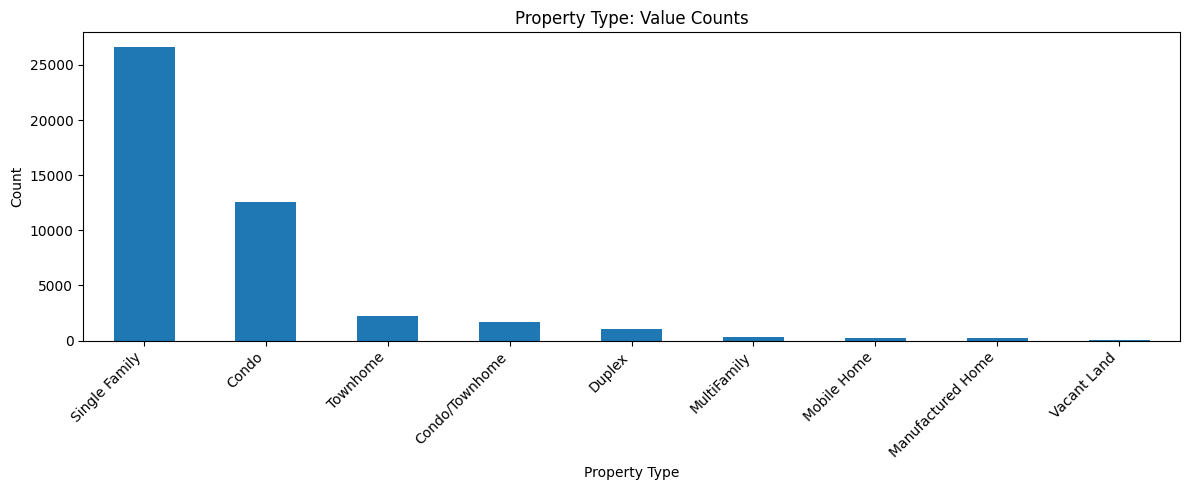

In [5]:
import matplotlib.pyplot as plt

property_type_counts = df_no_nan['Property Type'].value_counts(dropna=False).sort_values(ascending=False)
print(property_type_counts)

plt.figure(figsize=(12, 5))
property_type_counts.plot(kind='bar')
plt.title('Property Type: Value Counts')
plt.xlabel('Property Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# Remove anything that is not: ["Single Family", "Condo", "Townhome", "Condo/Townhome"]
df_no_nan = df_no_nan[df_no_nan['Property Type'].isin(["Single Family", "Condo", "Townhome", "Condo/Townhome"])]
print(df_no_nan.shape)  

(43104, 18)


This dropped us from 44896 to 43104 rows, still with 18 columns, including our output: Price.

The other benefit here is this likely removed some other data that was likely marginalized.
For example, we know there were 439 rows where "Bedrooms" was actually 0.0.
Now there are 415.

But, Bedrooms = 0 might just be code for "studio", which is possible. The more concerning would be
Bathrooms = 0; what does that mean? Acreage = 0 could just be code for apartment/condo?

In [7]:
print((df_no_nan["Bedrooms"] <= 0.0).sum())
zero_bedrooms_rows = df_no_nan.loc[df_no_nan["Bedrooms"] == 0.0].copy()

print(f"Rows with Bedrooms = 0.0: {len(zero_bedrooms_rows)}")
display(zero_bedrooms_rows)

415
Rows with Bedrooms = 0.0: 415


,City,Province,Latitude,Longitude,Price,Bedrooms,Bathrooms,Acreage,Property Type,Square Footage,Garage,Parking,Fireplace,Waterfront,Sewer,Pool,Garden,Balcony
179,Big White,BC,49.721928,-118.925423,205000.0,0.0,1.0,0.00,Condo,462.0,No,Yes,No,No,municipal,No,No,No
207,Langley,BC,49.157610,-122.657681,589900.0,0.0,1.0,0.00,Condo,791.0,Yes,Yes,Yes,No,none,No,No,No
224,Surrey,BC,49.190813,-122.826820,409900.0,0.0,1.0,0.00,Condo,383.0,Yes,Yes,No,No,none,No,No,No
397,Coquitlam,BC,49.285773,-122.795780,624900.0,0.0,2.0,0.00,Condo,996.0,Yes,Yes,No,No,none,No,No,No
450,Vancouver,BC,49.251826,-123.237580,758800.0,0.0,1.0,0.00,Condo,471.0,Yes,Yes,No,No,none,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44175,Prince Albert,SK,53.199628,-105.801147,799900.0,0.0,0.0,0.00,Single Family,840.0,Yes,No,No,No,none,No,No,No
44639,Saskatoon,SK,52.117692,-106.682691,89900.0,0.0,0.0,0.07,Single Family,670.0,No,No,No,No,none,No,No,No
44670,Saskatoon,SK,52.133867,-106.671592,260000.0,0.0,2.0,0.14,Single Family,2360.0,No,Yes,No,No,none,No,No,No
44671,Saskatoon,SK,52.123927,-106.678563,105000.0,0.0,1.0,0.07,Single Family,338.0,No,Yes,No,No,none,No,No,No


What I notice here is Bedrooms, Bathrooms, and Acreage can all be 0.00.
This is likely because some properties are listed as "Studio" or "Loft"
(which may have 0 bedrooms) or "Condo/Townhome" (which may have 0 acreage).


### Data output

We intend to use `Price` as our output class. We'll decide if we're doing a binary classifier, multi-class, or regression later.

We still have >43k rows with 17 feature columns, categorical and numeric. We should be good.

In [8]:
# show the dtypes
df_no_nan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43104 entries, 0 to 44895
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            43104 non-null  object 
 1   Province        43104 non-null  object 
 2   Latitude        43104 non-null  float64
 3   Longitude       43104 non-null  float64
 4   Price           43104 non-null  float64
 5   Bedrooms        43104 non-null  float64
 6   Bathrooms       43104 non-null  float64
 7   Acreage         43104 non-null  float64
 8   Property Type   43104 non-null  object 
 9   Square Footage  43104 non-null  float64
 10  Garage          43104 non-null  object 
 11  Parking         43104 non-null  object 
 12  Fireplace       43104 non-null  object 
 13  Waterfront      43104 non-null  object 
 14  Sewer           43104 non-null  object 
 15  Pool            43104 non-null  object 
 16  Garden          43104 non-null  object 
 17  Balcony         43104 non-null  obje

## Kris pre-processing

In [27]:
# convert the string data to integers
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder() # init the encoder

df = df_no_nan.copy() # make a copy of the dataframe to work with

for cols in df: # loop through the features
    if df[cols].dtype == 'str': # find the features with string data
        df[cols] = encoder.fit_transform(df[cols]) # convert the string data to unique integers

In [28]:
# convert the 'Bedrooms' and 'Bathrooms' features to be integers

df[['Bedrooms', 'Bathrooms']] = df[['Bedrooms', 'Bathrooms']].astype(int)

# convert the 'Square Footage' and 'Acreage' data to be categorical in preparation for cross featuring

df['Square Footage'], bin_limits = pd.qcut(df['Square Footage'], q = 10, labels = False, retbins = True, duplicates = 'drop')
df['Acreage'], bin_limits = pd.qcut(df['Acreage'], q = 10, labels = False, retbins = True, duplicates = 'drop')
print(f'the limits of the Square Footage bins are:\n{bin_limits}')
print(f'the limits of the Acreage bins are:\n{bin_limits}')

# we will need to also categorize the latitude and longitude here

the limits of the Square Footage bins are:
[0.0e+00 6.0e-02 1.1e-01 1.6e-01 2.2e-01 6.8e-01 8.6e+03]
the limits of the Acreage bins are:
[0.0e+00 6.0e-02 1.1e-01 1.6e-01 2.2e-01 6.8e-01 8.6e+03]


In [29]:
# verify that all features are numeric
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44896 entries, 0 to 44895
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   City            44896 non-null  object 
 1   Province        44896 non-null  object 
 2   Latitude        44896 non-null  float64
 3   Longitude       44896 non-null  float64
 4   Price           44896 non-null  float64
 5   Bedrooms        44896 non-null  int64  
 6   Bathrooms       44896 non-null  int64  
 7   Acreage         44896 non-null  int64  
 8   Property Type   44896 non-null  object 
 9   Square Footage  44896 non-null  int64  
 10  Garage          44896 non-null  object 
 11  Parking         44896 non-null  object 
 12  Fireplace       44896 non-null  object 
 13  Waterfront      44896 non-null  object 
 14  Sewer           44896 non-null  object 
 15  Pool            44896 non-null  object 
 16  Garden          44896 non-null  object 
 17  Balcony         44896 non-null 

As demonstrated above, all features which were originally made up of string data have been converted to unique integers. This ensures that the data is all numeric and will still allow the use of embedding or one hot encoding later in the notebook.

There are no new features added to the dataset. So far, we have only cleaned up the data and modified the string data to be integers. 

We believe that all of the features shown above are of value and should be kept for the model. Although we originally wanted to drop the latitude and longitude features since we already have 'City' and 'Province' to cover geographic characters, we believe those two features would be useful for the model to characterize expensive neighborhoods or homes in which its price is heavily driven by a special location in a city. 

Below is where we will add our crossed features

In [30]:
# first we will separate the data into target and training data

df_train = df.drop(columns = 'Price') # define the train data
df_test = df['Price'] # define the test data

In [31]:
# now let's create some different crossed values

# ideas for crossing features:
# property type x square footage (captures price variation due to home type despite size)
# city x square footage (captures city-specific cost of living despite home size)
# city x acreage (captures city-specific cost of living despite land size)
# latitude x longitude would a good cross to highlight expensive neighborhoods to the model
    # need categorize into roughly neighborhood sized regions before crossing 

# choose these as a class, what makes sense??
cross_columns = [['Property Type', 'Square Footage'],
                 ['City', 'Square Footage']
                ]

# cross each set of columns in the list above
cross_col_df_names = []
for cols_list in cross_columns:
    # encode as ints for the embedding
    enc = LabelEncoder()
    
    # 1. create crossed labels by join operation
    X_crossed_train = df_train[cols_list].apply(lambda x: '_'.join(x), axis=1)
    X_crossed_test = df_test[cols_list].apply(lambda x: '_'.join(x), axis=1)
    
    # get a nice name for this new crossed column
    cross_col_name = '_'.join(cols_list)
    
    # 2. encode as integers, stacking all possibilities
    enc.fit(np.hstack((X_crossed_train.to_numpy(),  X_crossed_test.to_numpy())))
    
    # 3. Save into dataframe with new name
    df_train[cross_col_name] = enc.transform(X_crossed_train)
    df_test[cross_col_name] = enc.transform(X_crossed_test)
    
    # Save the encoder used here for later:
    encoders[cross_col_name] = enc
    
    # keep track of the new names of the crossed columns
    cross_col_df_names.append(cross_col_name) 
    
cross_col_df_names

TypeError: sequence item 1: expected str instance, int found

To evaluate the model performance, the metric we will use is...

In [ ]:
# separate the data into target and training data
X = df_train.to_numpy() # convert to np array
y = df_test.to_numpy() # convert to np array

In [ ]:
# divide the dataset into train and test data
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)

for index_train, index_test in skf.split(X, y): 
    X_train, X_test = X[index_train], X[index_test]
    y_train, y_test = y[index_train], y[index_test]

/Users/kristoffermatsson/Desktop/Matsson/GitHub_Cloned_Repositories/MachineLearningNotebooks/.conda/lib/python3.11/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


We are selecting Stratified K-fold for our train/test split operation. This is to ensure that our split is well distributed with an full representation of the data for each training operation of the model. For example, if we used one random shuffle of the data, there is a chance that sklearn would randomly choose the test data to be easily predictable targets out of pure luck. The Stratified K fold will cross validate to tell us whether our model performance is consistent across all the data and not just because the train/test split choose convenience values for our model. 

In [ ]:
# scale the train/test data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # init the scalar
X_train = scaler.fit_transform(X_train) # calc the mean / std dev of the train data and scale
X_test = scaler.transform(X_test) # scale the test data based on stats from train data 

In [ ]:
# verify the data shapes
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (13695, 18)
X_test shape: (1521, 18)
y_train shape: (13695,)
y_test shape: (1521,)


In [ ]:
import os
os.environ['AUTOGRAPH_VERBOSITY'] = '0'

from sklearn import metrics as mt
import tensorflow as tf
from tensorflow import keras


print(tf.__version__)
print(keras.__version__)

2.16.2
3.14.0


## Kris Modeling

We will start modeling below

In [ ]:
# get crossed columns
X_train_crossed = df_train[cross_col_df_names].to_numpy()
X_test_crossed = df_test[cross_col_df_names].to_numpy()

# save categorical features
X_train_cat = df_train[categorical_headers_ints].to_numpy() 
X_test_cat = df_test[categorical_headers_ints].to_numpy() 

# and save off the numeric features
X_train_num =  df_train[numeric_headers].to_numpy()
X_test_num = df_test[numeric_headers].to_numpy()


# we need to create separate lists for each branch
crossed_outputs = []

# CROSSED DATA INPUT
input_crossed = Input(shape=(X_train_crossed.shape[1],), dtype='int64', name='wide_inputs')
for idx,col in enumerate(cross_col_df_names):
    
    # track what the maximum integer value will be for this variable
    # which is the same as the number of categories
    N = max(df_train[col].max(),df_test[col].max())+1
    N = len(encoders[col].classes_)
    N_reduced = int(np.sqrt(N))
    
    
    # this line of code does this: input_branch[:,idx]
    x = tf.gather(input_crossed, idx, axis=1)
    
    # now use an embedding to deal with integers as if they were one hot encoded
    x = Embedding(input_dim=N, 
                  output_dim=N_reduced, 
                  input_length=1, name=col+'_embed')(x)
    
    # save these outputs to concatenate later
    crossed_outputs.append(x)
    

# now concatenate the outputs and add a fully connected layer
wide_branch = concatenate(crossed_outputs, name='wide_concat')

# reset this input branch
all_deep_branch_outputs = []

# CATEGORICAL DATA INPUT
input_cat = Input(shape=(X_train_cat.shape[1],), dtype='int64', name='categorical_input')
for idx,col in enumerate(categorical_headers_ints):
    
    # track what the maximum integer value will be for this variable
    # which is the same as the number of categories
    N = max(df_train[col].max(),df_test[col].max())+1
    N_reduced = int(np.sqrt(N))
    
    # this line of code does this: input_branch[:,idx]
    x = tf.gather(input_cat, idx, axis=1)
    
    # now use an embedding to deal with integers as if they were one hot encoded
    x = Embedding(input_dim=N, 
                  output_dim=N_reduced, 
                  input_length=1, name=col+'_embed')(x)
    
    # save these outputs to concatenate later
    all_deep_branch_outputs.append(x)
    
# NUMERIC DATA INPUT
# create dense input branch for numeric
input_num = Input(shape=(X_train_num.shape[1],), name='numeric')
x_dense = Dense(units=20, activation='relu',name='num_1')(input_num)
    
all_deep_branch_outputs.append(x_dense)


# merge the deep branches together
deep_branch = concatenate(all_deep_branch_outputs,name='concat_embeds')
deep_branch = Dense(units=50,activation='relu', name='deep1')(deep_branch)
deep_branch = Dense(units=25,activation='relu', name='deep2')(deep_branch)
deep_branch = Dense(units=10,activation='relu', name='deep3')(deep_branch)
    
# merge the deep and wide branch
final_branch = concatenate([wide_branch, deep_branch],
                           name='concat_deep_wide')
final_branch = Dense(units=1,activation='sigmoid',
                     name='combined')(final_branch)

model = Model(inputs=[input_crossed,input_cat,input_num], 
              outputs=final_branch)



In [ ]:
# you will need to install pydot properly on your machine to get this running
plot_model(
    model, to_file='model.png', show_shapes=True, show_layer_names=True,
    rankdir='LR', expand_nested=False, dpi=96
)
# model.summary()

In [ ]:
%%time

model.compile(optimizer='adagrad',
              loss='mean_squared_error',
              metrics=['accuracy'])

# lets also add the history variable to see how we are doing
# and lets add a validation set to keep track of our progress
history = model.fit([X_train_crossed,X_train_cat,X_train_num],
                    y_train, 
                    epochs=15, 
                    batch_size=32, 
                    verbose=1, 
                    validation_data = ([X_test_crossed,X_test_cat,X_test_num],y_test))

In [ ]:
history = model.fit([X_train_crossed,X_train_cat,X_train_num],
                    y_train, 
                    epochs=50, 
                    batch_size=32, 
                    verbose=0, 
                    validation_data = ([X_test_crossed,X_test_cat,X_test_num],y_test))

In [ ]:
yhat = np.round(model.predict([X_test_crossed,X_test_cat,X_test_num]))
print(mt.confusion_matrix(y_test,yhat))
print(mt.classification_report(y_test,yhat))

In [ ]:
from matplotlib import pyplot as plt

%matplotlib inline

plt.figure(figsize=(10,4))
plt.subplot(2,2,1)
plt.plot(history.history['accuracy'])

plt.ylabel('Accuracy %')
plt.title('Training')
plt.subplot(2,2,2)
plt.plot(history.history['val_accuracy'])
plt.title('Validation')

plt.subplot(2,2,3)
plt.plot(history.history['loss'])
plt.ylabel('Training Loss')
plt.xlabel('epochs')

plt.subplot(2,2,4)
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')

## Mike Pre-processing

In [70]:
# Let's divide our 18 columns of data into: target, then features: categorical, discretized, and numeric.
# We will use the categorical features to create crossed features for the wide branch of our model,
# and we will use the numeric features in the deep branch of our model.
# The categorical features will also be used in the deep branch of our model as well.

# In general, to use TensorFlow/Keras, need feature names to NOT include spaces.
# For example:
# "Property Type" -> "Property_Type"
# "Square Footage_bin" -> "Square_Footage_bin"
safe_name_map = {
    c: (
        c.strip()
         .replace(" ", "_")
         .replace("/", "_")
         .replace("-", "_")
    )
    for c in df_no_nan.columns
}
df_model = df_no_nan.rename(columns=safe_name_map)

target_col = "Price"
feature_cols = sorted([c for c in df_model.columns if c != target_col])

# Identify categorical columns by their type.
categorical_headers = [
    c for c in feature_cols
    if c in df_model.select_dtypes(include=["object", "category", "string"]).columns
]

# Everything else is numeric after preprocessing
numeric_headers = [c for c in feature_cols if c not in categorical_headers]

# We can discretized a few numeric columns since that seems to both improve performance
# and make these features more useful for crossing in the wide branch of our model.
discretized_source_headers = sorted([c for c in ["Square_Footage", "Acreage"] if c in numeric_headers])
discretized_headers = [f"{c}_bin" for c in discretized_source_headers]

continuous_numeric_headers = [c for c in numeric_headers if c not in discretized_source_headers]

print(f"Target: {target_col}")
print(f"Categorical: {categorical_headers}")
print(f"Discretized: {discretized_headers}")
print(f"Continuous numeric: {continuous_numeric_headers}")

Target: Price
Categorical: ['Balcony', 'City', 'Fireplace', 'Garage', 'Garden', 'Parking', 'Pool', 'Property_Type', 'Province', 'Sewer', 'Waterfront']
Discretized: ['Acreage_bin', 'Square_Footage_bin']
Continuous numeric: ['Bathrooms', 'Bedrooms', 'Latitude', 'Longitude']


### Set up discretized features as _bins

In [71]:
# Let's discretize Acreage and Square Footage into 20 quantiles each,
# which will give us 20 categories for each of these features to use in the wide branch of our model.
#
# We'll label discretized features with a "_bin" suffix to make it clear that these are binned versions of the original continuous features.

for col in discretized_source_headers:
    df_model[f"{col}_bin"] = pd.qcut(
        df_model[col], q=20, labels=False, duplicates="drop"
    ).astype("int64")

# Keep only the binned versions for these features.
df_model.drop(columns=discretized_source_headers, inplace=True)

# Rebuild numeric header groups from the model dataframe after dropping raw columns.
numeric_headers = [c for c in df_model.columns if c not in categorical_headers + [target_col]]
continuous_numeric_headers = [c for c in numeric_headers if c not in discretized_headers]
print(f"Continuous numeric: {continuous_numeric_headers}")

Continuous numeric: ['Latitude', 'Longitude', 'Bedrooms', 'Bathrooms']


In [72]:
# After evaluation, I want to discretize more numeric features so they can be
# used as crossed features in the wide branch of our model. Let's consider
# Bedrooms and Bathrooms, which are already low-cardinality but have some 0.00 values that need special handling.

bedrooms_zero_count = (df_model["Bedrooms"] == 0.0).sum()
bathrooms_zero_count = (df_model["Bathrooms"] == 0.0).sum()
print(f'Count of df_model["Bedrooms"] == 0.0: {bedrooms_zero_count}')
print(f'Count of df_model["Bathrooms"] == 0.0: {bathrooms_zero_count}')

# Bathrooms/Bedrooms are low-cardinality already, but explicit bins are fine
# Sanitize values so casting cannot fail on NaN/inf/out-of-range values.
bedrooms_num = pd.to_numeric(df_model["Bedrooms"], errors="coerce")
bedrooms_num = bedrooms_num.replace([np.inf, -np.inf], np.nan).fillna(0.0)

df_model["Bedrooms_bin"] = pd.cut(
    bedrooms_num,
    bins=[-np.inf, 0, 1, 2, 3, 4, 5, np.inf],
    labels=False,
    include_lowest=True,
).astype("int64")

bathrooms_num = pd.to_numeric(df_model["Bathrooms"], errors="coerce")
bathrooms_num = bathrooms_num.replace([np.inf, -np.inf], np.nan).fillna(0.0)

df_model["Bathrooms_bin"] = pd.cut(
    bathrooms_num,
    bins=[-np.inf, 0, 1, 2, 3, 4, 5, np.inf],
    labels=False,
    include_lowest=True,
).astype("int64")

Count of df_model["Bedrooms"] == 0.0: 415
Count of df_model["Bathrooms"] == 0.0: 258


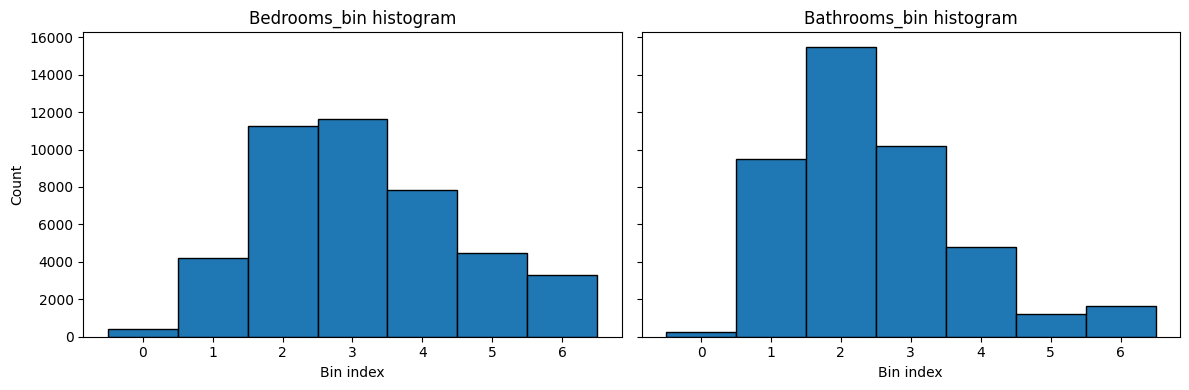

In [73]:
# Visiualize the distributions of the new bins.
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, col in zip(axes, ["Bedrooms_bin", "Bathrooms_bin"]):
    vals = df_model[col].dropna().astype(int)
    lo, hi = vals.min(), vals.max()
    edges = np.arange(lo - 0.5, hi + 1.5, 1)

    ax.hist(vals, bins=edges, edgecolor="black")
    ax.set_xticks(np.arange(lo, hi + 1))
    ax.set_xlabel("Bin index")
    ax.set_title(f"{col} histogram")

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

In [74]:
# Let's try binning latitude/longitude as well, for crossing, to capture
# neighborhood effects.
df_model["Latitude_bin"] = pd.qcut(
    df_model["Latitude"], q=30, labels=False, duplicates="drop"
).astype("int64")

df_model["Longitude_bin"] = pd.qcut(
    df_model["Longitude"], q=30, labels=False, duplicates="drop"
).astype("int64")


### Split the data into train and test sets

Also separates target from features.

In [75]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["Price"]).copy()
y = df_model["Price"].astype("float32").copy()

# Stratify by quantile bins of Price. We'll use these bins
# to create a multiclass target for stratification, but the model
# will still train to predict the original continuous price values.
price_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,  # 70/30 train/test split - pretty typical for small datasets
    random_state=42,
    stratify=price_bins
)

### Set up Crossed Features

Establishing a dimensionality for the crossed feature pairs is a fun exercise.
We'll pick a value between the observed # of actual rows in our training data
and the theoretical max which is #unique-crossed1 * #unique-crossed2.

In our case we chose 1.5 * #observed pairs.

In [76]:
# Now set up the 5 crossed features we want to create for the wide branch of our model.
cross_pairs = [
    ("City", "Property_Type"),
    ("City", "Square_Footage_bin"),
    ("Province", "Property_Type"),
    ("Bedrooms_bin", "Bathrooms_bin"),
    ("Latitude_bin", "Longitude_bin"),
]

# Compute data-driven crossing dimensions.
# We size each hash space from observed pair cardinality, capped by theoretical max.
rows = []
for a, b in cross_pairs:
    n_a = X_train[a].nunique(dropna=True)
    n_b = X_train[b].nunique(dropna=True)
    theoretical_max = int(n_a * n_b)
    observed_pairs = int(X_train[[a, b]].drop_duplicates().shape[0])

    suggested_dim = int(min(theoretical_max, max(32, np.ceil(observed_pairs * 1.5))))

    rows.append(
        {
            "pair": (a, b),
            "n_unique_a": int(n_a),
            "n_unique_b": int(n_b),
            "theoretical_max": theoretical_max,
            "observed_pairs": observed_pairs,
            "selected_crossing_dim": suggested_dim,
        }
    )

cross_stats = pd.DataFrame(rows)
display(cross_stats)

# Keys match cross_pairs and are used by FeatureSpace.cross below.
cross_dims = {
    row["pair"]: int(row["selected_crossing_dim"])
    for _, row in cross_stats.iterrows()
}

print("selected cross_dims =")
for k, v in cross_dims.items():
    print(f"  {k}: {v}")

,pair,n_unique_a,n_unique_b,theoretical_max,observed_pairs,selected_crossing_dim
0,"(City, Property_Type)",2633,4,10532,3059,4589
1,"(City, Square_Footage_bin)",2633,20,52660,7542,11313
2,"(Province, Property_Type)",11,4,44,37,44
3,"(Bedrooms_bin, Bathrooms_bin)",7,7,49,47,49
4,"(Latitude_bin, Longitude_bin)",30,30,900,381,572


selected cross_dims =
  ('City', 'Property_Type'): 4589
  ('City', 'Square_Footage_bin'): 11313
  ('Province', 'Property_Type'): 44
  ('Bedrooms_bin', 'Bathrooms_bin'): 49
  ('Latitude_bin', 'Longitude_bin'): 572


In [77]:
# From 10a. Keras Wide and Deep as TFData.ipynb.
#
# Finally, set up the Keras preprocessing layers for the crossed features, categorical features,
# and numeric features.
#
# Use the Keras FeatureSpace utility to manage all of the preprocessing for us,
# including learning normalization parameters from the training data and applying
# the same transformations to the test data.

import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

from sklearn import metrics as mt
import tensorflow as tf
from tensorflow import keras

print(tf.__version__)
print(keras.__version__)


2.19.0
3.13.2


In [118]:
# From 10a. Keras Wide and Deep as TFData.ipynb.

from tensorflow.keras.layers import Dense, Activation, Input, Dropout
from tensorflow.keras.layers import Embedding, Concatenate, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model

from tensorflow.keras.utils import FeatureSpace

# Crossing columns together 
feature_space = FeatureSpace(
    features={
        # Categorical feature encoded as string
        "Balcony":       FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "City":          FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Fireplace":     FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Garage":        FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Garden":        FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Parking":       FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Pool":          FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Property_Type": FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Province":      FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Sewer":         FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),
        "Waterfront":    FeatureSpace.string_categorical(num_oov_indices=1, output_mode='int'),

        "Acreage_bin":        FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        "Bathrooms_bin":      FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        "Bedrooms_bin":       FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        "Latitude_bin":       FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        "Longitude_bin":      FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        "Square_Footage_bin": FeatureSpace.integer_categorical(num_oov_indices=1, output_mode="int"),
        
        # Numerical features to normalize (normalization will be learned)
        # learns the mean, variance, and if to invert (3 parameters)
        "Bathrooms": FeatureSpace.float_normalized(),
        "Bedrooms":  FeatureSpace.float_normalized(),
        "Latitude":  FeatureSpace.float_normalized(),
        "Longitude": FeatureSpace.float_normalized(),
    },
    # Specify feature cross with a custom crossing dim
    crosses=[
        FeatureSpace.cross(
            feature_names=pair,
            crossing_dim=cross_dims[pair],
            output_mode="int",
        )
        for pair in cross_pairs
    ],
    output_mode="dict",
)

### Set up Tensorflow tf.data

In [119]:
# Now we can use the feature space to preprocess our data
# and create tf.data datasets for training and evaluation.
# tf.data datasets
batch_size = 256  # set for efficiency, but can be tuned as a hyperparameter

ds_train = tf.data.Dataset.from_tensor_slices((dict(X_train), y_train.values))
ds_train = ds_train.shuffle(len(X_train), seed=42).batch(batch_size).prefetch(tf.data.AUTOTUNE)

ds_test = tf.data.Dataset.from_tensor_slices((dict(X_test), y_test.values))
ds_test = ds_test.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [120]:
# From 10a. Keras Wide and Deep as TFData.ipynb.

# Here we use the training data and our feature space with crossed features
# to learn the necessary transformations and normalization parameters for all of our features.
# This is the part where instead of us manually converting categorical features to integers,
# and then manually learning mean and variance for normalization, the feature space does all of that for us.
train_ds_with_no_labels = ds_train.map(lambda x, _: x)
feature_space.adapt(train_ds_with_no_labels)

preprocessed_ds_train = ds_train.map(lambda x, y: (feature_space(x), y), 
                                     num_parallel_calls=tf.data.AUTOTUNE)
preprocessed_ds_train = preprocessed_ds_train.prefetch(tf.data.AUTOTUNE)

preprocessed_ds_test = ds_test.map(lambda x, y: (feature_space(x), y), num_parallel_calls=tf.data.AUTOTUNE)
preprocessed_ds_test = preprocessed_ds_test.prefetch(tf.data.AUTOTUNE)


In [121]:
# From 10a. Keras Wide and Deep as TFData.ipynb.

def setup_embedding_from_encoding_crossing(encoded_features, feature_space, col_name):
    # what the maximum integer value for this variable?
    
    # get the size of the feature
    x = encoded_features[col_name]
    # get the size of the feature
    N = feature_space.crossers[col_name].num_bins
    N_embed = int(np.sqrt(N))
    print(f'Crossing: {col_name} from {N} OHE to {N_embed} features.')
    
    # now use an embedding to deal with integers as if they were one hot encoded
    x = Embedding(input_dim=N, 
                  output_dim=N_embed, 
                  name=col_name+'_embed')(x)
    
    
    x = Flatten()(x) # get rid of that pesky extra dimension (for time of embedding)
    
    return x

def setup_embedding_from_encoding_categorical(encoded_features, feature_space, col_name):
    # what the maximum integer value for this variable?
    
    # get the size of the feature
    x = encoded_features[col_name]
    # get the size of the feature
    N = len(feature_space.preprocessors[col_name].get_vocabulary())
    N_embed = int(np.sqrt(N))
    
    print(f'Category Embed: {col_name} from {N} OHE to {N_embed} features.')
    
    # now use an embedding to deal with integers as if they were one hot encoded
    x = Embedding(input_dim=N, 
                  output_dim=N_embed, 
                  name=col_name+'_embed')(x)
    
    
    x = Flatten()(x) # get rid of that pesky extra dimension (for time of embedding)
    
    return x

dict_inputs = feature_space.get_inputs() # need to use unprocessed features here, to gain access to each output
encoded_feature_tensors = feature_space.get_encoded_features() # these features have been encoded

# Build explicitly named encoded inputs so dict keys match tensor names exactly.
encoded_features = {
    col: keras.Input(
        shape=tensor.shape[1:],
        dtype=tensor.dtype,
        name=col
    )
    for col, tensor in encoded_feature_tensors.items()
}

# we need to create separate lists for each branch
crossed_outputs = []

# for each crossed variable, make an embedding
for col in feature_space.crossers.keys():
    
    x = setup_embedding_from_encoding_crossing(encoded_features, feature_space, col)
    
    # save these outputs in list to concatenate later
    crossed_outputs.append(x)
    

# now concatenate the outputs and add a fully connected layer
wide_branch = Concatenate(name='wide_concat')(crossed_outputs)

# reset this input branch
all_deep_branch_outputs = []

# for each numeric variable, just add it in after embedding
for col in numeric_headers:
    x = encoded_features[col]
    #x = tf.cast(x,float) # cast an integer as a float here
    all_deep_branch_outputs.append(x)
    
# for each categorical variable
for col in categorical_headers:
    
    # get the output tensor from ebedding layer
    x = setup_embedding_from_encoding_categorical(encoded_features,feature_space, col)
    
    # save these outputs in list to concatenate later
    all_deep_branch_outputs.append(x)

# Ensure every declared encoded input is connected to the graph.
used_feature_keys = set(feature_space.crossers.keys()) | set(numeric_headers) | set(categorical_headers)
for col in sorted(encoded_features.keys()):
    if col not in used_feature_keys:
        all_deep_branch_outputs.append(encoded_features[col])



Crossing: City_X_Property_Type from 4589 OHE to 67 features.
Crossing: City_X_Square_Footage_bin from 11313 OHE to 106 features.
Crossing: Province_X_Property_Type from 44 OHE to 6 features.
Crossing: Bedrooms_bin_X_Bathrooms_bin from 49 OHE to 7 features.
Crossing: Latitude_bin_X_Longitude_bin from 572 OHE to 23 features.
Category Embed: Balcony from 3 OHE to 1 features.
Category Embed: City from 2634 OHE to 51 features.
Category Embed: Fireplace from 3 OHE to 1 features.
Category Embed: Garage from 3 OHE to 1 features.
Category Embed: Garden from 3 OHE to 1 features.
Category Embed: Parking from 3 OHE to 1 features.
Category Embed: Pool from 3 OHE to 1 features.
Category Embed: Property_Type from 5 OHE to 2 features.
Category Embed: Province from 12 OHE to 3 features.
Category Embed: Sewer from 6 OHE to 2 features.
Category Embed: Waterfront from 3 OHE to 1 features.


### Analysis

This is pretty cool. We now have a number of interesting features, including
these crossed features which may be more useful signals for Price.
Notice how the dimensionality for the OHE features is significantly
less than it would have been.

## Mike Modeling


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Balcony             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ City (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Fireplace           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garage (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garden (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Parking             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pool (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Property_Type       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Province            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Sewer (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Waterfront          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Balcony_embed       │ (None, 1, 1)      │          3 │ Balcony[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ City_embed          │ (None, 1, 51)     │    134,334 │ City[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Fireplace_embed     │ (None, 1, 1)      │          3 │ Fireplace[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garage_embed        │ (None, 1, 1)      │          3 │ Garage[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Garden_embed        │ (None, 1, 1)      │          3 │ Garden[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Parking_embed       │ (None, 1, 1)      │          3 │ Parking[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pool_embed          │ (None, 1, 1)      │          3 │ Pool[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,660,372 (6.33 MB)

 Trainable params: 1,660,372 (6.33 MB)

 Non-trainable params: 0 (0.00 B)

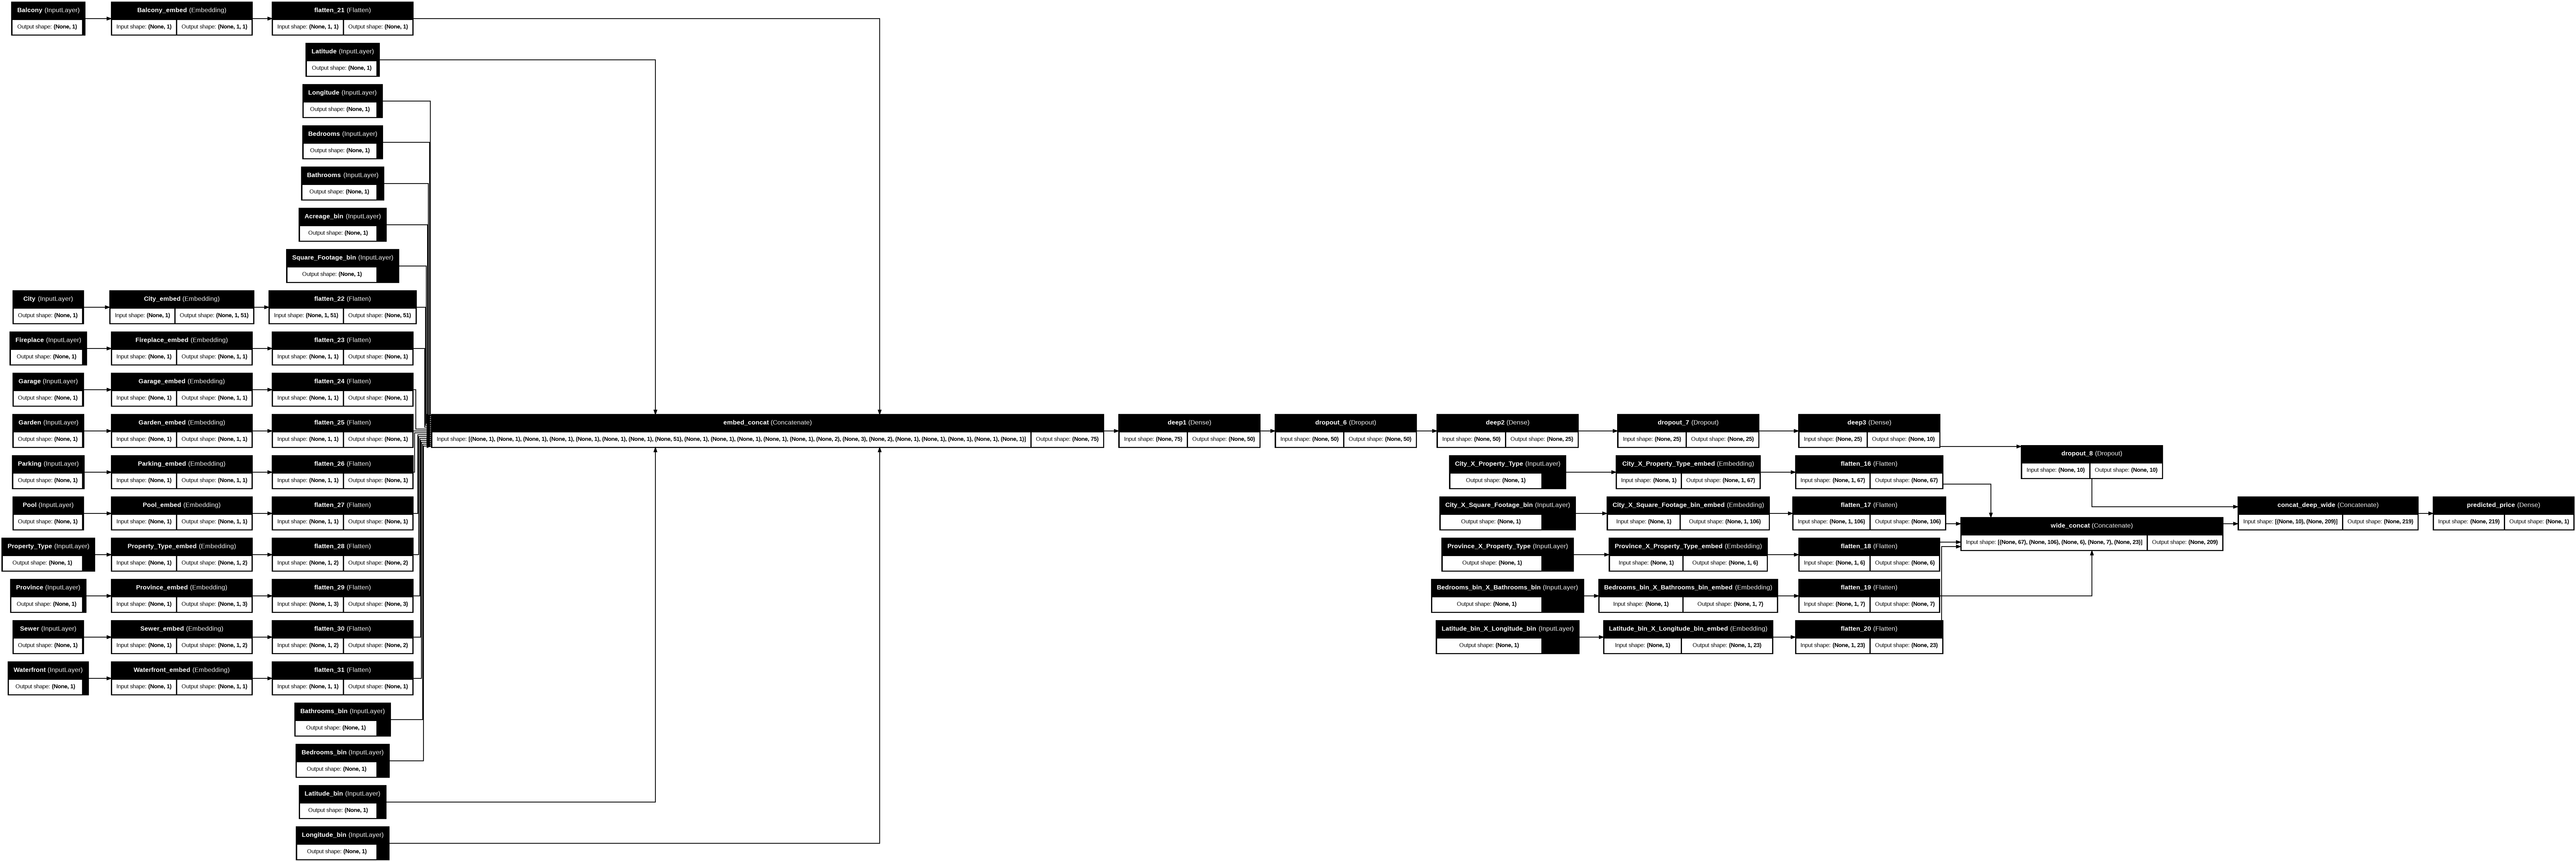

In [127]:
# From 10a. Keras Wide and Deep as TFData.ipynb.

# merge the deep branches together
deep_branch = Concatenate(name='embed_concat')(all_deep_branch_outputs)
deep_branch = Dense(units=50,activation='relu', name='deep1')(deep_branch)
deep_branch = Dropout(0.6)(deep_branch)
deep_branch = Dense(units=25,activation='relu', name='deep2')(deep_branch)
deep_branch = Dropout(0.4)(deep_branch)
deep_branch = Dense(units=10,activation='relu', name='deep3')(deep_branch)
deep_branch = Dropout(0.2)(deep_branch)
    
# merge the deep and wide branch
final_branch = Concatenate(name='concat_deep_wide')([deep_branch, wide_branch])

# Now final output for regression uses linear activation, not sigmoid.
final_branch = Dense(units=1, activation='linear',
                     name='predicted_price')(final_branch)

# encoded features input, fast
training_model = keras.Model(inputs=encoded_features, outputs=final_branch)

# Uses MSE loss for regression, and tracks MAE and RMSE as metrics,
# whereas before this used binary crossentropy loss and accuracy metrics for classification.
training_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")]
 )

training_model.summary()

# non-encoded: use the encoded tensors that are already connected to dict_inputs
inference_output = training_model(encoded_feature_tensors)
inference_model = keras.Model(inputs=dict_inputs, outputs=inference_output)
inference_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")]
 )


plot_model(
    training_model, to_file='model.png', show_shapes=True, show_layer_names=True,
    rankdir='LR', expand_nested=False, dpi=96
)

In [128]:
# Re-compile before fit to ensure a fresh optimizer state after graph/name edits.
# Primary regression metrics: MAE and RMSE.
training_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="mse",
    metrics=[
        "mae",
        keras.metrics.RootMeanSquaredError(name="rmse"),
    ]
)

history = training_model.fit(
    preprocessed_ds_train, epochs=30, validation_data=preprocessed_ds_test, verbose=2
)

Epoch 1/30
118/118 - 10s - 85ms/step - loss: 3219626917888.0000 - mae: 1071989.6250 - rmse: 1794331.8750 - val_loss: 3401010905088.0000 - val_mae: 1067866.7500 - val_rmse: 1844183.0000
Epoch 2/30
118/118 - 5s - 41ms/step - loss: 3177302458368.0000 - mae: 1055920.0000 - rmse: 1782498.8750 - val_loss: 3262497685504.0000 - val_mae: 1014231.3125 - val_rmse: 1806238.5000
Epoch 3/30
118/118 - 4s - 36ms/step - loss: 2741942353920.0000 - mae: 875464.7500 - rmse: 1655881.1250 - val_loss: 2428796403712.0000 - val_mae: 654919.0000 - val_rmse: 1558459.6250
Epoch 4/30
118/118 - 4s - 34ms/step - loss: 1921264779264.0000 - mae: 626924.6250 - rmse: 1386097.0000 - val_loss: 1845976629248.0000 - val_mae: 586065.6250 - val_rmse: 1358667.2500
Epoch 5/30
118/118 - 3s - 27ms/step - loss: 1746806243328.0000 - mae: 647246.2500 - rmse: 1321668.0000 - val_loss: 1781486583808.0000 - val_mae: 580728.8125 - val_rmse: 1334723.3750
Epoch 6/30
118/118 - 6s - 52ms/step - loss: 1727228411904.0000 - mae: 634390.6875 - r

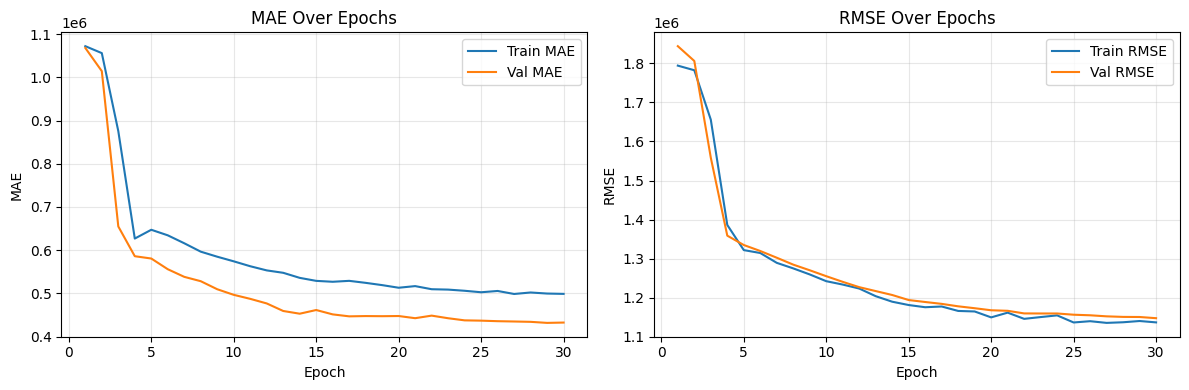

In [133]:
from matplotlib import pyplot as plt

%matplotlib inline

epochs = range(1, len(history.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# MAE over epochs
axes[0].plot(epochs, history.history["mae"], label="Train MAE")
axes[0].plot(epochs, history.history["val_mae"], label="Val MAE")
axes[0].set_title("MAE Over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMSE over epochs
axes[1].plot(epochs, history.history["rmse"], label="Train RMSE")
axes[1].plot(epochs, history.history["val_rmse"], label="Val RMSE")
axes[1].set_title("RMSE Over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Holdout metrics - training_model:
  mae: 432593.1250
  rmse: 1147237.1250

Holdout metrics - inference_model:
  mae: 432593.1250
  rmse: 1147237.1250


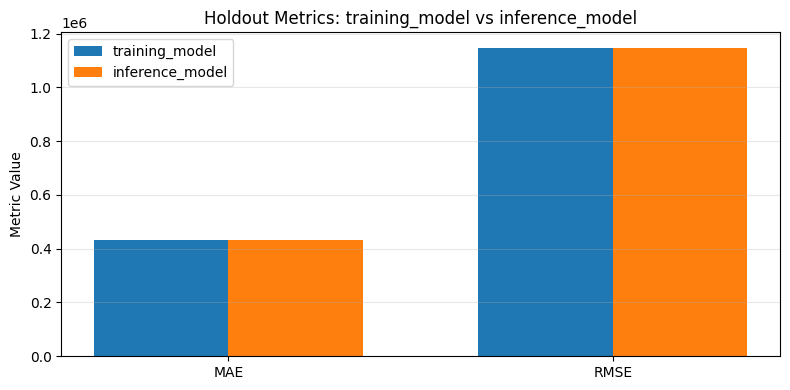

In [134]:
# Compare holdout performance: training_model (encoded input path) vs inference_model (raw input path).
# Compute MAE/RMSE directly from predictions to avoid metric-name differences across TF/Keras versions.
y_true = y_test.to_numpy().reshape(-1)

y_pred_train = training_model.predict(preprocessed_ds_test, verbose=0).reshape(-1)

# Ensure raw dict inputs match inference_model's expected per-feature shape: (batch, 1).
def _reshape_for_inference(feature_dict, target):
    reshaped = {}
    for k, v in feature_dict.items():
        reshaped[k] = tf.expand_dims(v, axis=-1) if len(v.shape) == 1 else v
    return reshaped, target

ds_test_for_inference = ds_test.map(_reshape_for_inference, num_parallel_calls=tf.data.AUTOTUNE)
ds_test_for_inference = ds_test_for_inference.prefetch(tf.data.AUTOTUNE)

y_pred_infer = inference_model.predict(ds_test_for_inference, verbose=0).reshape(-1)

train_results = {
    "mae": float(np.mean(np.abs(y_true - y_pred_train))),
    "rmse": float(np.sqrt(np.mean((y_true - y_pred_train) ** 2))),
}
infer_results = {
    "mae": float(np.mean(np.abs(y_true - y_pred_infer))),
    "rmse": float(np.sqrt(np.mean((y_true - y_pred_infer) ** 2))),
}

print("Holdout metrics - training_model:")
for k, v in train_results.items():
    print(f"  {k}: {v:.4f}")

print("\nHoldout metrics - inference_model:")
for k, v in infer_results.items():
    print(f"  {k}: {v:.4f}")

# Plot MAE and RMSE comparison across both models on holdout data.
metrics_to_plot = ["mae", "rmse"]
x = np.arange(len(metrics_to_plot))
width = 0.35

train_vals = [train_results[m] for m in metrics_to_plot]
infer_vals = [infer_results[m] for m in metrics_to_plot]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width / 2, train_vals, width, label="training_model")
ax.bar(x + width / 2, infer_vals, width, label="inference_model")

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics_to_plot])
ax.set_ylabel("Metric Value")
ax.set_title("Holdout Metrics: training_model vs inference_model")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Exceptional Work

### Arturo update: model-depth comparison and regression evaluation

To match the Lab 5 rubric, this section extends the existing regression wide-and-deep workflow by:

1. Training additional wide-and-deep variants with different numbers of hidden layers in the deep branch.
2. Comparing those variants against the MLP baseline.
3. Using regression-focused evaluation, including residual variance and Bland-Altman style analysis.

This directly addresses the rubric requirements for:
- at least three combined wide and deep networks,
- altering the number of layers in the deep branch,
- and comparing the best wide and deep model to a standard MLP for a regression task.


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Dropout, Concatenate
import matplotlib.pyplot as plt

def build_wd_from_encoded(encoded_features, feature_space, numeric_headers, categorical_headers, hidden_units):
    from tensorflow.keras.layers import Embedding, Flatten

    def setup_embedding_from_encoding_crossing(encoded_features, feature_space, col_name):
        x = encoded_features[col_name]
        N = feature_space.crossers[col_name].num_bins
        N_embed = int(np.ceil(np.sqrt(N)))
        x = Embedding(input_dim=N, output_dim=N_embed, name=f"{col_name}_embed")(x)
        x = Flatten()(x)
        return x

    def setup_embedding_from_encoding_categorical(encoded_features, feature_space, col_name):
        x = encoded_features[col_name]
        N = len(feature_space.preprocessors[col_name].get_vocabulary())
        N_embed = int(np.ceil(np.sqrt(N)))
        x = Embedding(input_dim=N, output_dim=N_embed, name=f"{col_name}_embed")(x)
        x = Flatten()(x)
        return x

    crossed_outputs = []
    for col in feature_space.crossers.keys():
        crossed_outputs.append(setup_embedding_from_encoding_crossing(encoded_features, feature_space, col))
    wide_branch = Concatenate(name=f'wide_concat_{"_".join(map(str,hidden_units))}')(crossed_outputs)

    deep_parts = []
    for col in numeric_headers:
        deep_parts.append(encoded_features[col])

    for col in categorical_headers:
        deep_parts.append(setup_embedding_from_encoding_categorical(encoded_features, feature_space, col))

    used_feature_keys = set(feature_space.crossers.keys()) | set(numeric_headers) | set(categorical_headers)
    for col in encoded_features.keys():
        if col not in used_feature_keys:
            deep_parts.append(encoded_features[col])

    deep_branch = Concatenate(name=f'embed_concat_{"_".join(map(str,hidden_units))}')(deep_parts)

    for i, units in enumerate(hidden_units, start=1):
        deep_branch = Dense(units=units, activation='relu', name=f'deep_{len(hidden_units)}layers_{i}')(deep_branch)
        deep_branch = Dropout(0.2, name=f'dropout_{len(hidden_units)}layers_{i}')(deep_branch)

    final_branch = Concatenate(name=f'concat_deep_wide_{"_".join(map(str,hidden_units))}')([deep_branch, wide_branch])
    output = Dense(units=1, activation='linear', name=f'predicted_price_{"_".join(map(str,hidden_units))}')(final_branch)

    model = Model(inputs=feature_space.get_inputs(), outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

variant_specs = {
    "wd_1layer": [32],
    "wd_2layer": [64, 32],
    "wd_3layer": [64, 32, 16]
}

wd_results = []
wd_histories = {}
wd_predictions = {}

for model_name, hidden_units in variant_specs.items():
    print(f"Training {model_name} with hidden units {hidden_units}")
    model = build_wd_from_encoded(encoded_features, feature_space, numeric_headers, categorical_headers, hidden_units)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        verbose=1
    )

    preds = model.predict(dict(X_test_df), verbose=0).reshape(-1)
    residuals = y_test.to_numpy().reshape(-1) - preds

    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))
    resid_var = np.var(residuals, ddof=1)

    wd_histories[model_name] = history.history
    wd_predictions[model_name] = preds
    wd_results.append({
        "model": model_name,
        "layers": len(hidden_units),
        "hidden_units": str(hidden_units),
        "mae": float(mae),
        "rmse": float(rmse),
        "residual_variance": float(resid_var)
    })

wd_results_df = pd.DataFrame(wd_results).sort_values("rmse").reset_index(drop=True)
display(wd_results_df)

best_wd_name = wd_results_df.loc[0, "model"]
best_wd_preds = wd_predictions[best_wd_name]

print(f"Best wide/deep model: {best_wd_name}")

plt.figure(figsize=(8,5))
for model_name, hist in wd_histories.items():
    plt.plot(hist["val_loss"], label=f"{model_name} val_loss")
plt.title("Validation Loss Across Wide & Deep Variants")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

residuals_best = y_test.to_numpy().reshape(-1) - best_wd_preds
means_best = (y_test.to_numpy().reshape(-1) + best_wd_preds) / 2

plt.figure(figsize=(8,5))
plt.scatter(means_best, residuals_best, alpha=0.35)
plt.axhline(np.mean(residuals_best), linestyle='--')
plt.axhline(np.mean(residuals_best) + 1.96*np.std(residuals_best), linestyle=':')
plt.axhline(np.mean(residuals_best) - 1.96*np.std(residuals_best), linestyle=':')
plt.title(f"Bland-Altman Style Plot: {best_wd_name}")
plt.xlabel("Mean of Actual and Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()
